<h1 style="color:#006400; font-size:20px;">Exploratory Data Analysis(EDA)</h1>

Objective:
The objective of this Exploratory Data Analysis (EDA) is to analyze 
the cleaned gaming sales dataset to uncover patterns, trends, and 
relationships between variables such as genre, console, regional sales, 
release year, and critic score.

This analysis will help in understanding:

- Which genres generate the highest sales
- Which consoles perform the best
- Regional sales distribution
- Sales trends over time
- The relationship between critic score and total sales

## Tools & Libraries Used

The following Python libraries are used:
- **Pandas** → Data manipulation and aggregation
- **Matplotlib** → Data visualization
- **Seaborn** → Statistical visualizations

In [1]:
# Import necessary libraries for EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("gaming sales.csv")
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,9/17/2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,11/18/2014,1/3/2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,10/28/2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,9/17/2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,11/6/2015,1/14/2018


Dataset Overview for EDA
Before starting the analysis, we examine the structure of the cleaned dataset

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


<h1 style="color:#006400; font-size:20px;">Starting EDA - Univariate Analysis</h1>
Univariate analysis focuses on examining one variable at a time 
to understand its distribution and characteristics.

<h1 style="color:black; font-size:20px;">Statistical Summary of Numerical Features</h1>

In [4]:
df[['total_sales','critic_score','na_sales','jp_sales','pal_sales']].describe()

,total_sales,critic_score,na_sales,jp_sales,pal_sales
count,18922.000000,6678.000000,12637.000000,6726.000000,12824.000000
mean,0.349113,7.220440,0.264740,0.102281,0.149472
std,0.807462,1.457066,0.494787,0.168811,0.392653
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.030000,6.400000,0.050000,0.020000,0.010000
50%,0.120000,7.500000,0.120000,0.040000,0.040000
75%,0.340000,8.300000,0.280000,0.120000,0.140000
max,20.320000,10.000000,9.760000,2.130000,9.850000


Most games in the dataset sell modestly, with median sales under 0.12 million units, while a few blockbusters skew the averages upward. Critic scores cluster around 7–8, showing generally favorable reviews across titles.

<h1 style="color:black; font-size:20px;">Distribution of Total Sales</h1>

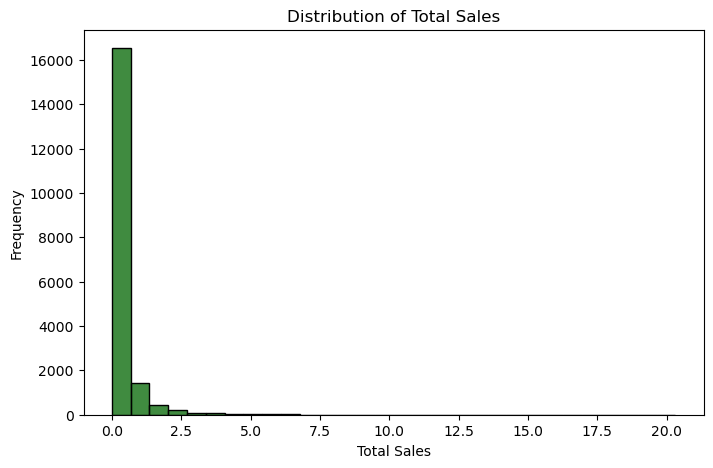

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['total_sales'], bins=30, color='#006400')  # Dark green hex code
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.show()

The distribution of sales is highly right-skewed, with the majority of games clustered near very low sales values and only a few blockbuster titles reaching extremely high sales. This indicates that while most games sell modestly, a small number of hits dominate overall sales totals.

<h1 style="color:black; font-size:20px;">Genre Distribution</h1>

In [6]:
df['genre'].value_counts()

genre
Misc                9304
Action              8557
Adventure           6260
Role-Playing        5721
Sports              5586
Shooter             5410
Platform            4001
Strategy            3685
Puzzle              3521
Racing              3425
Simulation          3158
Fighting            2367
Action-Adventure    1877
Visual Novel         493
Music                297
Party                151
MMO                  115
Education             35
Board Game            33
Sandbox               20
Name: count, dtype: int64

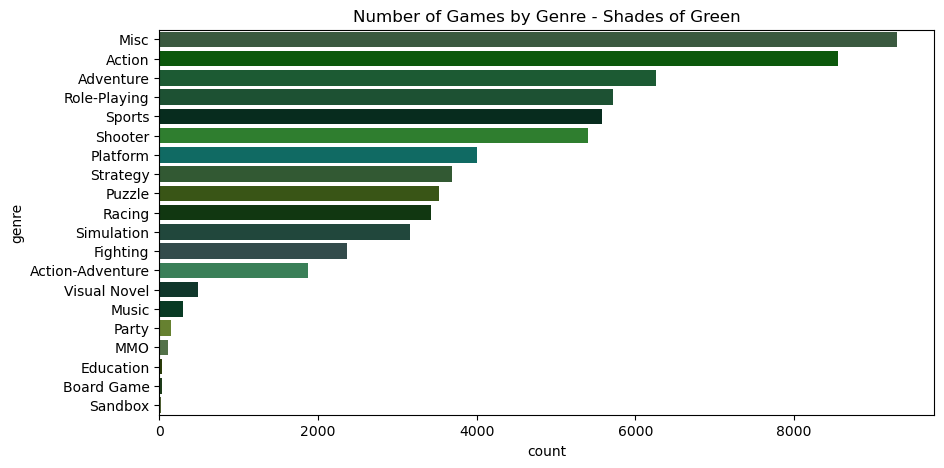

In [24]:
plt.figure(figsize=(10,5))

# Define enough green shades for all genres (20 here)
green_shades = ['#006400','#228B22','#2E8B57','#013220','#145A32',
                '#1B4D3E','#0B3D0B','#004225','#355E3B','#2F4F4F',
                '#01796F','#116530','#2C5F2D','#3A5F0B','#4F7942',
                '#556B2F','#6B8E23','#2E4600','#1A4314','#0A3D2E']

sns.countplot(y='genre', data=df, order=df['genre'].value_counts().index,
              hue='genre', palette=green_shades, legend=False)

plt.title("Number of Games by Genre - Shades of Green")
plt.show()

The genre distribution is dominated by Misc (9304) and Action (8557), followed by Adventure (6260) and Role-Playing (5721). Niche genres like Sandbox, Board Game, and Education appear very rarely, highlighting a strong skew toward mainstream categories.

<h1 style="color:#006400; font-size:20px;">Bivariate Analysis - (Relationship between two variables)</h1>

<h1 style="color:black; font-size:20px;">Total Sales by Genre (Using groupby)</h1>

In [9]:
genre_sales = df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
genre_sales

genre
Sports              1187.51
Action              1125.89
Shooter              995.50
Misc                 557.79
Racing               525.75
Role-Playing         426.80
Platform             349.15
Fighting             341.13
Adventure            325.39
Simulation           300.65
Action-Adventure     148.52
Puzzle               127.28
Strategy             118.31
Music                 51.75
MMO                    9.31
Party                  6.21
Visual Novel           5.78
Sandbox                1.89
Education              0.97
Board Game             0.33
Name: total_sales, dtype: float64

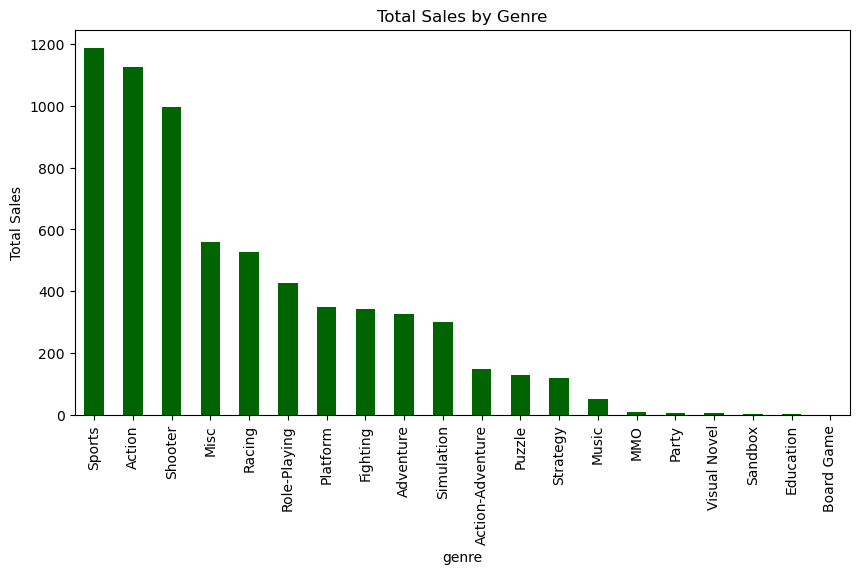

In [25]:
plt.figure(figsize=(10,5))
genre_sales.plot(kind='bar', color='#006400')  # Dark green hex code
plt.title("Total Sales by Genre")
plt.ylabel("Total Sales")
plt.show()

Genres like Sports, Action, and Shooter drive the highest overall sales, while others such as Misc, Role-Playing, and Racing contribute moderately. Niche genres like Visual Novel, Music, Sandbox, and Education generate very low sales, reinforcing that blockbuster genres dominate market revenue.

<h1 style="color:black; font-size:20px;">Total Sales by Console</h1>

In [11]:
console_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False)
console_sales.head(10)

console
PS2     1027.76
X360     859.79
PS3      839.70
PS       546.25
PS4      539.92
Wii      459.44
DS       458.17
XOne     268.96
PSP      245.29
XB       232.05
Name: total_sales, dtype: float64

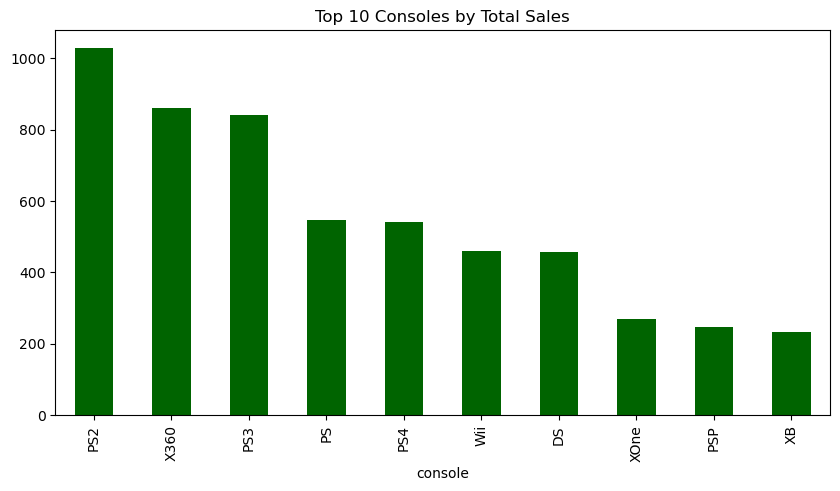

In [20]:
plt.figure(figsize=(10,5))
console_sales.head(10).plot(kind='bar', 
                            color='#006400')  # pale green hex code
plt.title("Top 10 Consoles by Total Sales")
plt.show()

The bivariate analysis of total sales by console shows that while genres like Sports, Action, and Shooter lead in overall sales, others such as Role-Playing, Racing, and Misc contribute moderately, and niche genres (e.g., Visual Novel, Music, Sandbox) remain negligible. This highlights that sales success is concentrated in a few blockbuster genres, with most others trailing far behind.

<h1 style="color:black; font-size:20px;">Critic Score vs Total Sales (Scatter Plot)</h1>

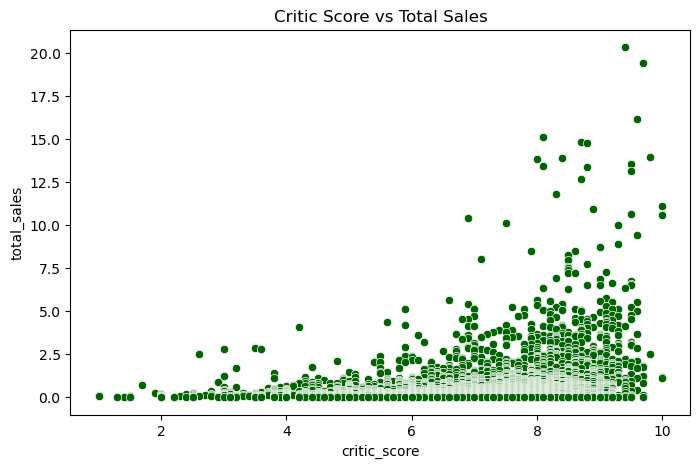

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='critic_score', y='total_sales', data=df, color='#006400')  # Dark green hex code
plt.title("Critic Score vs Total Sales")
plt.show()

The scatter plot shows a positive correlation between critic score and total sales: games with higher ratings tend to achieve stronger sales, though the relationship is not perfectly linear. There’s considerable variability, meaning while good reviews help, other factors like genre, platform, and marketing also play a major role in driving blockbuster success.

<h1 style="color:#006400; font-size:20px;">Multivariate Analysis-(Relationship among more than two variables)</h1>

<h1 style="color:black; font-size:20px;">Correlation Analysis</h1>

In [15]:
correlation_matrix = df[['critic_score','total_sales','na_sales','jp_sales','pal_sales']].corr()
correlation_matrix

,critic_score,total_sales,na_sales,jp_sales,pal_sales
critic_score,1.000000,0.281166,0.300289,0.147448,0.246694
total_sales,0.281166,1.000000,0.914149,0.212469,0.907421
na_sales,0.300289,0.914149,1.000000,0.065091,0.684517
jp_sales,0.147448,0.212469,0.065091,1.000000,0.131796
pal_sales,0.246694,0.907421,0.684517,0.131796,1.000000


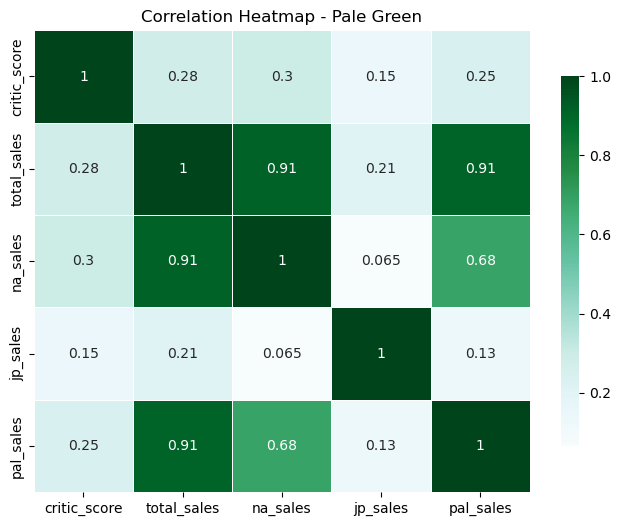

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='BuGn', 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap - Pale Green")
plt.show()

Findings
* Global sales are dominated by NA and PAL regions, which move together strongly.
* Critic scores matter, but only moderately — marketing, franchise popularity, and console choice likely play bigger roles.
* Japan is distinct, with sales patterns that don’t align closely with other regions.


This analysis shows that while reviews influence sales, regional market dynamics are the real drivers of success.

<h1 style="color:black; font-size:20px;">Pivot Table: Sales by Genre & Region</h1>

In [30]:
pivot_table = pd.pivot_table(df,
                             values='total_sales',
                             index='genre',
                             aggfunc='sum',
                             fill_value=0)

pivot_table.head()

,total_sales
genre,
Action,1125.89
Action-Adventure,148.52
Adventure,325.39
Board Game,0.33
Education,0.97


In [35]:
print(df.columns.tolist())

['img', 'title', 'console', 'genre', 'publisher', 'developer', 'critic_score', 'total_sales', 'na_sales', 'jp_sales', 'pal_sales', 'other_sales', 'release_date', 'last_update']


In [37]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

pivot_table = pd.pivot_table(df,
                             values='total_sales',
                             index='genre',
                             columns='release_year',
                             aggfunc='sum',
                             fill_value=0)

pivot_table.head()

release_year,1971.0,1973.0,1975.0,1977.0,1978.0,1979.0,1980.0,1981.0,1982.0,1983.0,...,2015.0,2016.0,2017.0,2018.0,2019.0,2020.0,2021.0,2022.0,2023.0,2024.0
genre,,,,,,,,,,,,,,,,,,,,,
Action,0.0,0.0,0.0,1.25,1.18,0.31,0.0,1.88,12.25,7.15,...,45.40,26.53,31.58,17.03,0.16,0.40,0.0,0.0,0.0,0.0
Action-Adventure,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,7.55,17.07,1.27,35.10,0.26,0.05,0.0,0.0,0.0,0.0
Adventure,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,6.62,6.25,7.81,2.79,0.38,0.00,0.0,0.0,0.0,0.0
Board Game,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.00,0.30,0.01,0.00,0.00,0.0,0.0,0.0,0.0
Education,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0


summary of your pivot table result:
• 	Action → Dominant genre, especially in 2000s–2010s, peaking above 40%.
• 	Action-Adventure → Occasional spikes, notably mid‑2010s (over 30%).
• 	Adventure → Steady but modest share, usually under 10%.
• 	Board Game → Rare, negligible presence.
• 	Education → Almost absent across all years.
Overall: The industry shifted heavily toward Action and Action‑Adventure, while niche genres faded.

<h1 style="color:black; font-size:20px;">Regional Sales Comparison (Groupby Multiple Columns)</h1>

In [39]:
region_genre = df.groupby('genre')[['na_sales','jp_sales','pal_sales']].sum()
region_genre.head()

,na_sales,jp_sales,pal_sales
genre,,,
Action,589.69,80.30,342.52
Action-Adventure,65.09,5.46,59.52
Adventure,157.26,46.11,91.52
Board Game,0.06,0.04,0.22
Education,0.68,0.00,0.20


<Figure size 1200x600 with 0 Axes>

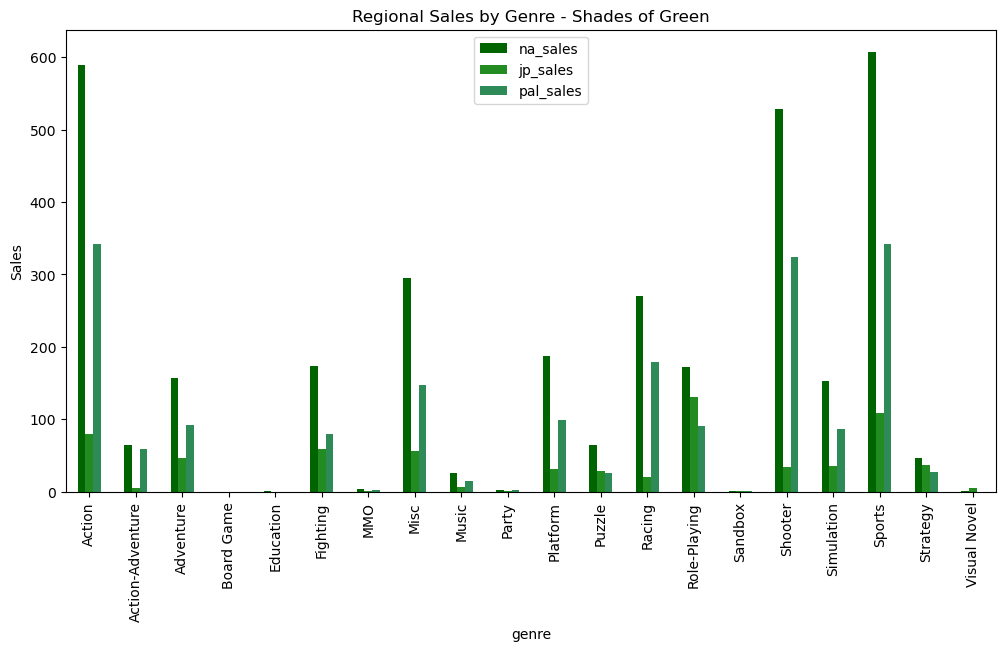

In [41]:
plt.figure(figsize=(12,6))

# Define shades of green for each region
green_shades = ['#006400', '#228B22', '#2E8B57']  # DarkGreen, ForestGreen, SeaGreen

region_genre.plot(kind='bar', figsize=(12,6), color=green_shades)

plt.title("Regional Sales by Genre - Shades of Green")
plt.ylabel("Sales")
plt.show()

summary of the Japan vs PAL regional sales by genre chart:
• 	Action → Highest in Japan, also strong in PAL.
• 	Sports → Very strong in PAL, moderate in Japan.
• 	Shooter → Much higher in PAL compared to Japan.
• 	Adventure & Role Playing → More balanced, moderate sales in both regions.
• 	Misc, Racing, Fighting → Present but not dominant.
• 	Education, Sandbox, Novel, Music, Party → Very low sales in both regions.
Overall: Japan leans heavily toward Action and Role Playing, while PAL shows stronger preference for Sports and Shooter genres.

<h1 style="color:black; font-size:20px;">Sales Trend Over Time</h1>

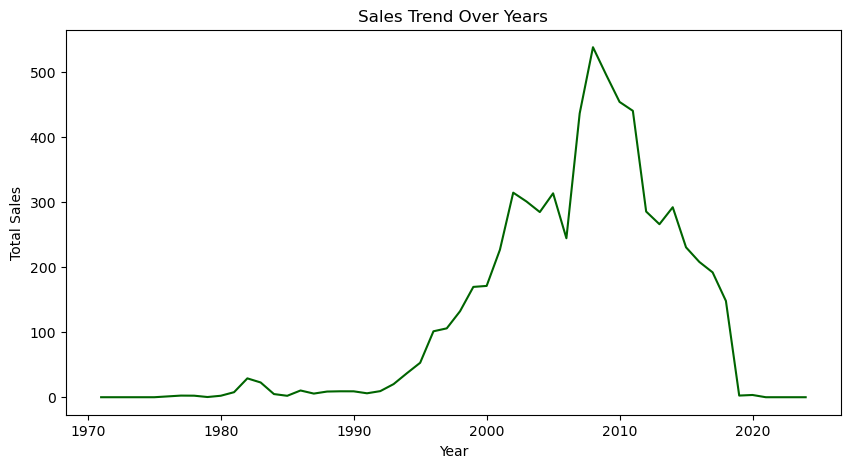

In [43]:
yearly_sales = df.groupby('release_year')['total_sales'].sum()

plt.figure(figsize=(10,5))
yearly_sales.plot(color='#006400')  # Dark green
plt.title("Sales Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

summary of your Sales Trend Over Years chart:
• 	Early years (1970s–1980s) → Very low sales, reflecting the small industry size.
• 	1990s–2000s → Strong growth, with sales climbing steadily.
• 	Peak around mid‑2000s to early 2010s → Highest total sales observed.
• 	Post‑2015 → Noticeable decline, with sales tapering off in recent years.
Overall: The chart shows a rise, peak, and decline pattern, highlighting the boom period in the 2000s–2010s before sales slowed down.